# Emission from a hemispherical cathode tip

A minimal example of the full pipeline:

1. Generate a flat (`z=0`) cathode-emission distribution with **distgen**.
2. Map it onto the surface of a hemispherical tip with
   `specific_particle_tracer.distributions.flat_distribution_to_hemisphere`.
3. Run it through `SpecificParticleTracer` with a `HemisphericalTip` geometry.
4. Plot the resulting trajectories.

This tracker models **individual real electrons**, not statistical macroparticles --
see `SpecificParticleTracer`'s docstring. Each particle below is given exactly one
elementary charge of weight, which the tracker would otherwise enforce anyway (with a
warning) if it weren't already true.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yaml

from distgen import Generator

from specific_particle_tracer import SpecificParticleTracer, HemisphericalTip
from specific_particle_tracer.distributions import flat_distribution_to_hemisphere
from specific_particle_tracer.constants import ELEMENTARY_CHARGE

%matplotlib inline


## 1. A flat cathode-emission distribution, via distgen

`start: {type: cathode}` places every particle at `z=0` with a longitudinal momentum
drawn from the given mean transverse energy (MTE) -- exactly the "flat, z=0"
distribution `flat_distribution_to_hemisphere` expects. `total_charge` is set to
`n_particle` elementary charges, so every particle carries exactly one real electron's
worth of charge (see the note above).


In [2]:
R = 50e-9          # tip radius [m]
n_particle = 60

distgen_input = f"""
n_particle: {n_particle}
species: electron
random:
  type: hammersley
  seed: 42
total_charge:
  units: C
  value: {n_particle * ELEMENTARY_CHARGE}
start:
  type: cathode
  MTE:
    value: 200
    units: meV
r_dist:
  type: radial_gaussian
  sigma_xy:
    value: 5
    units: nm
t_dist:
  type: uniform
  min_t:
    value: 0
    units: fs
  max_t:
    value: 50
    units: fs
fix_avg_and_stds: false
"""

gen = Generator(yaml.safe_load(distgen_input), verbose=0)
pg_flat = gen.run()
pg_flat


<ParticleGroup with 60 particles at 0x18a943117f0>

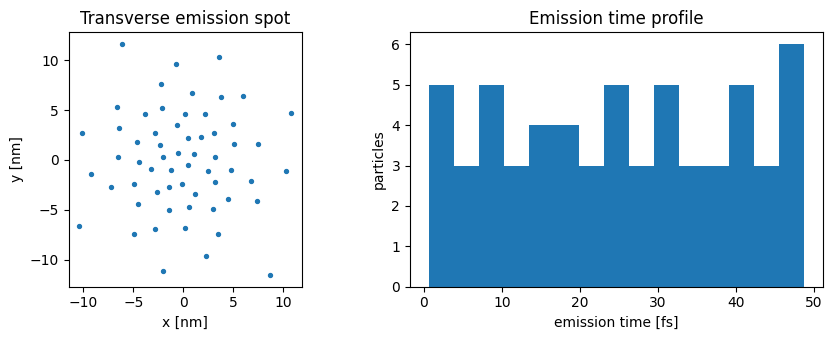

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

axes[0].scatter(pg_flat.x * 1e9, pg_flat.y * 1e9, s=8)
axes[0].set_xlabel("x [nm]")
axes[0].set_ylabel("y [nm]")
axes[0].set_title("Transverse emission spot")
axes[0].set_aspect("equal")

axes[1].hist(pg_flat.t * 1e15, bins=15)
axes[1].set_xlabel("emission time [fs]")
axes[1].set_ylabel("particles")
axes[1].set_title("Emission time profile")

fig.tight_layout()


## 2. Map the flat distribution onto the tip

Each particle's `(x, y)` is projected straight up onto the dome
(`z = sqrt(R^2 - x^2 - y^2)`), and its momentum is rotated so the flat cathode's
normal direction (+z) becomes the local outward (radial) direction at the tip.


In [4]:
pg_tip = flat_distribution_to_hemisphere(pg_flat, R)

r = np.sqrt(pg_tip.x**2 + pg_tip.y**2 + pg_tip.z**2)
print(f"radius range after mapping: {r.min()*1e9:.4f} to {r.max()*1e9:.4f} nm (R = {R*1e9:.1f} nm)")


radius range after mapping: 50.0000 to 50.0000 nm (R = 50.0 nm)


## 3. Run the tracer

`HemisphericalTip` bundles the analytic field (a uniform asymptotic field `E_gun`,
enhanced up to 3x right at the tip), the exact image-charge solution for the tip, and
the "re-entered the conductor" kill test. `t_out` asks for a full trajectory snapshot
(every already-born particle's position and momentum) at each of the given times --
that's what makes the trajectory plots below possible without any interpolation.


In [5]:
E_gun = -1e8  # V/m, asymptotic field far from the tip (negative: pushes electrons in +z)

geometry = HemisphericalTip(E_gun=E_gun, R=R, z0=3e-9)

t_max = 6e-13
t_out = np.linspace(0, t_max, 40)

tracer = SpecificParticleTracer(
    initial_particles=pg_tip,
    n_emit=1,
    geometry=geometry,
    screens=[R + 1e-6],   # 1 micron above the tip
    t_out=list(t_out),
    z_max=2e-6,           # stop tracking a particle once it's well past the screen
    t_max=t_max,
)

screens, trajectories = tracer.run(verbose=True)
(screen_pg,) = screens
print(f"{len(screen_pg)} of {n_particle} particles reached the screen")


88 accepted step-batches across 60 groups (backend=cpu)
60 of 60 particles reached the screen


## 4. Trajectory plots

`trajectories` is a list of `ParticleGroup`s, one per `t_out` value, each holding every
particle that has been born by that time (frozen at its last position if it was
already killed). Collecting each particle's own history across those snapshots (by
`id`) gives per-particle trajectories vs. time.


In [6]:
def collect_trajectories(trajectories):
    """Return {id: (t_array, pos_array (n,3), mom_array (n,3))} by following each
    particle's id across the list of per-time-snapshot ParticleGroups."""
    by_id = {}
    for traj in trajectories:
        for i, pid in enumerate(traj.id):
            t_list, pos_list, mom_list = by_id.setdefault(pid, ([], [], []))
            t_list.append(traj.t[i])
            pos_list.append((traj.x[i], traj.y[i], traj.z[i]))
            mom_list.append((traj.px[i], traj.py[i], traj.pz[i]))
    return {
        pid: (np.array(t_list), np.array(pos_list), np.array(mom_list))
        for pid, (t_list, pos_list, mom_list) in by_id.items()
    }


by_id = collect_trajectories(trajectories)
print(f"tracked {len(by_id)} particle trajectories")


tracked 60 particle trajectories


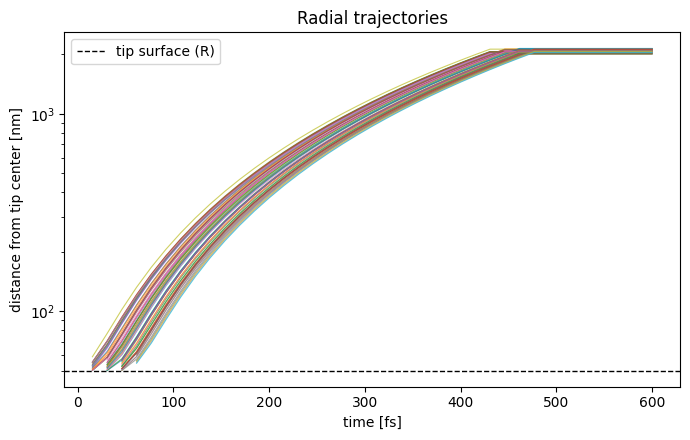

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for pid, (t, pos, mom) in by_id.items():
    r = np.linalg.norm(pos, axis=-1)
    ax.plot(t * 1e15, r * 1e9, lw=0.8, alpha=0.7)

ax.axhline(R * 1e9, color="k", lw=1, ls="--", label="tip surface (R)")
ax.set_xlabel("time [fs]")
ax.set_ylabel("distance from tip center [nm]")
ax.set_yscale("log")
ax.set_title("Radial trajectories")
ax.legend()
fig.tight_layout()


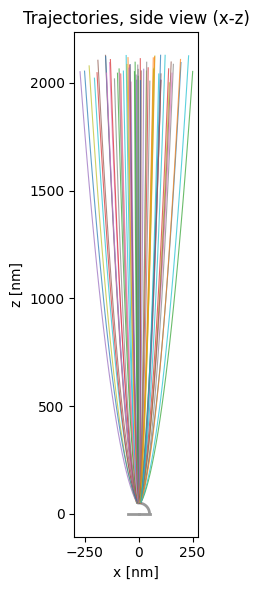

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))

# A little semicircle to show the tip cross-section.
theta = np.linspace(0, np.pi / 2, 100)
ax.plot(R * 1e9 * np.cos(theta), R * 1e9 * np.sin(theta), color="0.6", lw=2)
ax.plot([-R * 1e9, 0], [0, 0], color="0.6", lw=2)
ax.plot([0, R * 1e9], [0, 0], color="0.6", lw=2)

for pid, (t, pos, mom) in by_id.items():
    ax.plot(pos[:, 0] * 1e9, pos[:, 2] * 1e9, lw=0.8, alpha=0.7)

ax.set_xlabel("x [nm]")
ax.set_ylabel("z [nm]")
ax.set_title("Trajectories, side view (x-z)")
ax.set_aspect("equal")
fig.tight_layout()


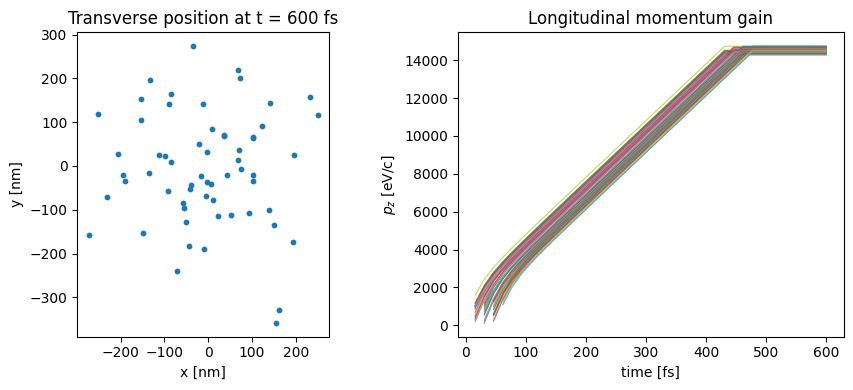

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

final_t, final_pos, final_mom = zip(*[(t[-1], pos[-1], mom[-1]) for t, pos, mom in by_id.values()])
final_pos = np.array(final_pos)
final_mom = np.array(final_mom)

axes[0].scatter(final_pos[:, 0] * 1e9, final_pos[:, 1] * 1e9, s=10)
axes[0].set_xlabel("x [nm]")
axes[0].set_ylabel("y [nm]")
axes[0].set_title(f"Transverse position at t = {t_max*1e15:.0f} fs")
axes[0].set_aspect("equal")

for pid, (t, pos, mom) in by_id.items():
    pz_ev_c = mom[:, 2]
    axes[1].plot(t * 1e15, pz_ev_c, lw=0.8, alpha=0.7)
axes[1].set_xlabel("time [fs]")
axes[1].set_ylabel("$p_z$ [eV/c]")
axes[1].set_title("Longitudinal momentum gain")

fig.tight_layout()
